# Genre prediction

### Import libraries

In [ ]:
import re
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import PorterStemmer

from datasets import load_dataset
from collections import Counter
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns
from tqdm import tqdm
import time

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.preprocessing import StandardScaler, LabelEncoder, MultiLabelBinarizer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.metrics import hamming_loss, accuracy_score
from sklearn.multioutput import MultiOutputClassifier

import torch
from transformers import BertTokenizer, BertModel

import pickle

### Read data and EDA

Upload data:

In [ ]:
df = pd.DataFrame(load_dataset("Iliasselyaa/CMUBookSummaryDataset", split="train"))

print(f"Total books: {len(df)}")
df.head()

Total books: 16559


,id,wikipedia_id,freebase_id,title,author,publication_date,genres,summary
0,0,620,/m/0hhy,Animal Farm,George Orwell,1945-08-17,"Roman à clef, Satire, Children's literature, S...","Old Major, the old boar on the Manor Farm, ca..."
1,1,843,/m/0k36,A Clockwork Orange,Anthony Burgess,1962,"Science Fiction, Novella, Speculative fiction,...","Alex, a teenager living in near-future Englan..."
2,2,986,/m/0ldx,The Plague,Albert Camus,1947,"Existentialism, Fiction, Absurdist fiction, Novel",The text of The Plague is divided into five p...
3,3,1756,/m/0sww,An Enquiry Concerning Human Understanding,David Hume,None,None,The argument of the Enquiry proceeds by a ser...
4,4,2080,/m/0wkt,A Fire Upon the Deep,Vernor Vinge,None,"Hard science fiction, Science Fiction, Specula...",The novel posits that space around the Milky ...


Visualization of genre distribution:

Number of unique genres: 227



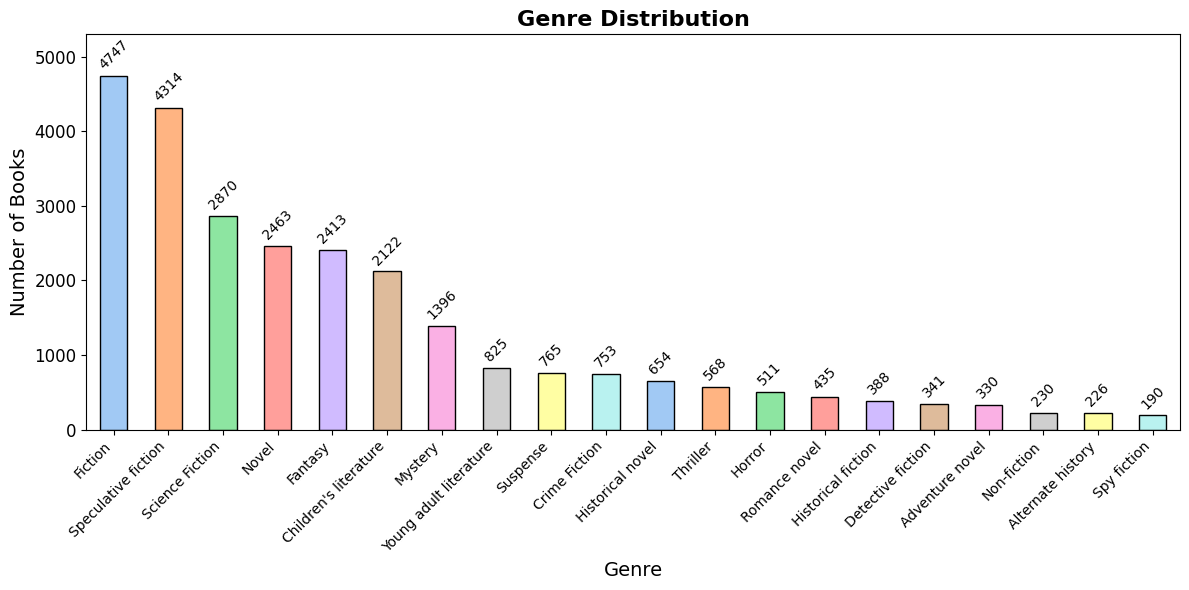

In [ ]:
def parse_genres(genres_str):
    """Function that translates strings with genres into a genre list"""

    if pd.isna(genres_str) or genres_str == '':
        return []
    return [g.strip() for g in genres_str.split(',')]

# Count all genres
df['genres_list'] = df['genres'].apply(parse_genres)
all_genres = []
for genres in df['genres_list']:
    all_genres.extend(genres)
genre_counter = Counter(all_genres)
print(f"Number of unique genres: {len(genre_counter)}\n")

genre_distribution = pd.DataFrame({
    'Genre': list(genre_counter.keys()),
    'Count': list(genre_counter.values())
}).sort_values('Count', ascending=False).head(20)  # take first 20 genres

# Bar chart creation
colors = sns.color_palette("pastel", len(genre_distribution))
plt.figure(figsize=(12, 6))
ax = genre_distribution.set_index('Genre')['Count'].plot(
    kind='bar',
    color=colors,
    edgecolor='black',
    linewidth=1.0
)

# Sign values over columns
for i, (genre, count) in enumerate(zip(genre_distribution['Genre'], genre_distribution['Count'])):
    ax.text(i, count + 50, str(count), ha='center', va='bottom', fontsize=10, rotation=45)

plt.title('Genre Distribution', fontsize=16, fontweight='bold')
plt.xlabel('Genre', fontsize=14)
plt.ylabel('Number of Books', fontsize=14)
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(fontsize=12)
plt.ylim(0, 5300)

plt.tight_layout()
plt.show()

Visualization of summary length distribution:

Max summary length: 10334



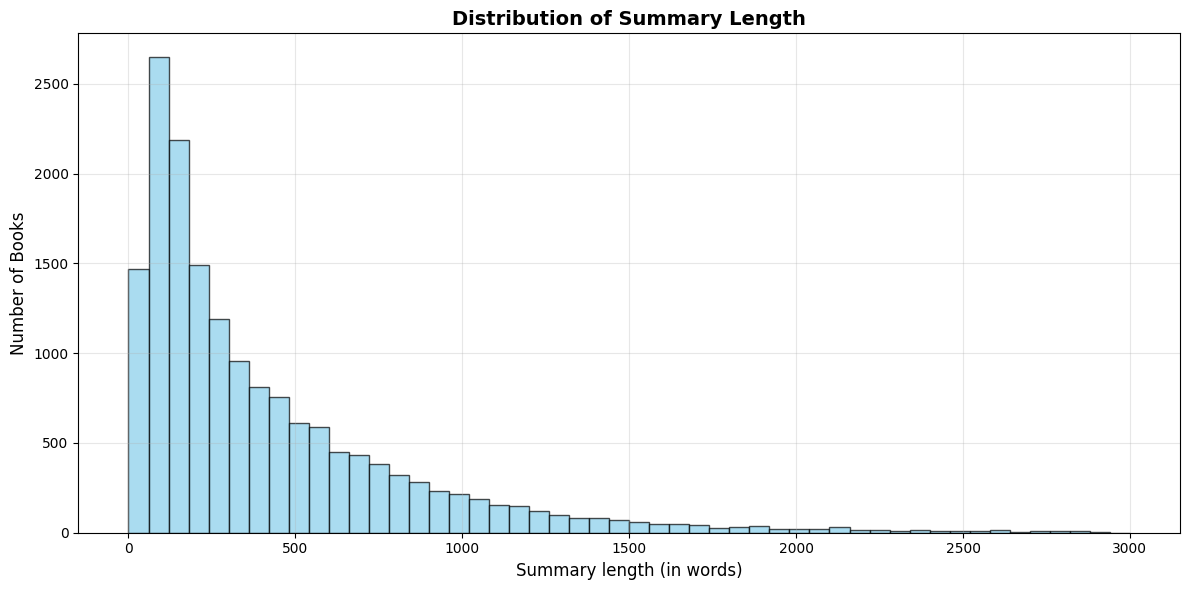

In [ ]:
# Summary length calculation
df['summary_length'] = df['summary'].apply(lambda x: len(str(x).split()) if pd.notna(x) else 0)
print(f"Max summary length: {df['summary_length'].max()}\n")

# Bar chart creation
plt.figure(figsize=(12, 6))
plt.hist(
    df['summary_length'],
    bins=50,
    range=(0, 3000),
    color='skyblue',
    edgecolor='black',
    alpha=0.7
)
plt.xlabel('Summary length (in words)', fontsize=12)
plt.ylabel('Number of Books', fontsize=12)
plt.title('Distribution of Summary Length', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Pre-processing

In [ ]:
GENRES_COUNT = 20  # number of target genres
target_genres = [genre for genre, count in genre_counter.most_common(GENRES_COUNT)]

print(f"Target genres:")
for i, genre in enumerate(target_genres):
    print(f"  {i+1}. {genre}")

# Leave only those books whose genre is part of the top
def has_top_genre(genres_list):
    return any(g in target_genres for g in genres_list)

df_filtered = df[df['genres_list'].apply(has_top_genre)].copy()
print(f"\nTotal books after filtration: {len(df_filtered)}")

Target genres:
  1. Fiction
  2. Speculative fiction
  3. Science Fiction
  4. Novel
  5. Fantasy
  6. Children's literature
  7. Mystery
  8. Young adult literature
  9. Suspense
  10. Crime Fiction
  11. Historical novel
  12. Thriller
  13. Horror
  14. Romance novel
  15. Historical fiction
  16. Detective fiction
  17. Adventure novel
  18. Non-fiction
  19. Alternate history
  20. Spy fiction

Total books after filtration: 12056


In [ ]:
def preprocess_text(text):
    """
    Summary text preprocessing:
    - Remove punctuation
    - Transform to lowercase
    - Remove stop-words
    """

    if pd.isna(text) or text == '':
        return ''
    text = re.sub(r'[^\w\s]', '', text, re.UNICODE)
    text = text.lower()
    text = [word for word in text.split() if word not in stopwords.words('english')]
    text = ' '.join(text)
    return text

# Truncate data to accelerate learning
DATA_SIZE = 2000
data = df_filtered[:DATA_SIZE]

# Preprocessing of summaries
nltk.download('stopwords')
nltk.download('punkt')
data['summary_preprocessed'] = data['summary'].apply(preprocess_text)

# Leave only necessary columns
data = data[['title', 'genres_list', 'summary_preprocessed']]
data.head()

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
/tmp/ipykernel_2571/2922579980.py:24: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['summary_preprocessed'] = data['summary'].apply(preprocess_text)


,title,genres_list,summary_preprocessed
0,Animal Farm,"[Roman à clef, Satire, Children's literature, ...",old major old boar manor farm calls animals fa...
1,A Clockwork Orange,"[Science Fiction, Novella, Speculative fiction...",alex teenager living nearfuture england leads ...
2,The Plague,"[Existentialism, Fiction, Absurdist fiction, N...",text plague divided five parts town oran thous...
4,A Fire Upon the Deep,"[Hard science fiction, Science Fiction, Specul...",novel posits space around milky way divided co...
6,A Wizard of Earthsea,"[Children's literature, Fantasy, Speculative f...",ged young boy gont one larger islands north ar...


In [ ]:
# Label matrix creation
mlb = MultiLabelBinarizer(classes=target_genres)
y = mlb.fit_transform(data['genres_list'])

X = data['summary_preprocessed']

# Split into train/test
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_label.py:909: UserWarning: unknown class(es) ['Absurdist fiction', 'Adventure', 'Albino bias', 'Anthropology', 'Anti-war', 'Apocalyptic and post-apocalyptic fiction', 'Autobiographical novel', 'Autobiography', 'Bildungsroman', 'Biographical novel', 'Biography', 'Black comedy', "Boys' school stories", 'Business', 'Cabal', 'Campus novel', 'Catastrophic literature', 'Chivalric romance', 'Comedy', 'Comedy of manners', 'Comic book', 'Comic fantasy', 'Comic novel', 'Comic science fiction', 'Comics', 'Conspiracy', 'Conspiracy fiction', 'Cozy', 'Cyberpunk', 'Dark fantasy', 'Drama', 'Dystopia', 'Economics', 'English public-school stories', 'Epistolary novel', 'Ergodic literature', 'Erotica', 'Existentialism', 'Experimental literature', 'Fairy tale', 'Fantasy of manners', 'Farce', 'Feminist science fiction', 'First-person narrative', 'Foreign legion', 'Gay Themed', 'Gay novel', 'Ghost story', 'Gothic fiction', 'Graphic novel', 'Hard 

Create new features in accordance with three techniques: Bage of wards, TF-IDF, BERT embeddings

In [ ]:
def extract_bert_embeddings(texts, batch_size=32):
    """Function for extraction BERT embeddings"""

    embeddings = []

    # Embedding extraction for each batch of texts
    for i in tqdm(range(0, len(texts), batch_size), desc="Extracting BERT embeddings"):
        batch_texts = texts[i:i+batch_size]

        # Batch tokenization
        inputs = tokenizer(batch_texts, return_tensors='pt', padding=True, truncation=True, max_length=512)

        with torch.no_grad():  # disable gradients
            outputs = model(**inputs)

        # Average over tokens
        batch_embeddings = outputs.last_hidden_state.mean(dim=1).numpy()
        embeddings.append(batch_embeddings)

    return np.vstack(embeddings)

# --- BOW ---
bow_vectorizer = CountVectorizer(max_features=5000, ngram_range=(1, 2))
X_train_bow = bow_vectorizer.fit_transform(X_train)
X_test_bow = bow_vectorizer.transform(X_test)

# --- TF-IDF ---
tfidf_vectorizer = TfidfVectorizer(max_features=5000, ngram_range=(1, 2), sublinear_tf=True)
X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)
X_test_tfidf = tfidf_vectorizer.transform(X_test)

# --- BERT ---
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')
model = BertModel.from_pretrained('bert-base-uncased')
model.eval()
X_train_bert = extract_bert_embeddings(X_train.tolist())
X_test_bert = extract_bert_embeddings(X_test.tolist())

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
Extracting BERT embeddings: 100%|██████████| 13/13 [14:35<00:00, 67.34s/it]


In [ ]:
print(f"BOW train shape: {X_train_bow.shape}")
print(f"BOW test shape: {X_test_bow.shape}")
print(f"TF-IDF train shape: {X_train_tfidf.shape}")
print(f"TF-IDF test shape: {X_test_tfidf.shape}")
print(f"BERT train shape: {X_train_bert.shape}")
print(f"BERT test shape: {X_test_bert.shape}")

BOW train shape: (1600, 5000)
BOW test shape: (400, 5000)
TF-IDF train shape: (1600, 5000)
TF-IDF test shape: (400, 5000)
BERT train shape: (1600, 768)
BERT test shape: (400, 768)


### Model training

In [ ]:
def evaluate_model(
    model,
    X_train,
    X_test,
    y_train,
    y_test
):
    """
    Trains and evaluates the classifier on the given data.

    Params:
    model (classifier object): Model
    X_train (array-like): Train features
    X_test (array-like): Test features
    y_train (array-like): Train labels
    y_test (array-like): Test labels

    Return:
    dict: Dictionary containing trained model, predictions for test sample,
          learning time, hamming loss, and accuracy for each class.
    """

    start_time = time.time()

    model.fit(X_train, y_train)
    train_time = time.time() - start_time

    y_pred = model.predict(X_test)

    h_loss = hamming_loss(y_test, y_pred)
    accuracy_per_class = dict()

    for i in range(y_test.shape[1]):
        accuracy_per_class[target_genres[i]] = accuracy_score(y_test[:, i], y_pred[:, i])

    return {
        'model': model,
        'y_pred': y_pred,
        'train_time': train_time,
        'hamming_loss': h_loss,
        'accuracy_per_class': accuracy_per_class
    }

# Classifiers creation
models = {
    'Logistic Regression': MultiOutputClassifier(
        LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced'),
        n_jobs=-1
    ),
    'Random Forest': MultiOutputClassifier(
        RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1),
        n_jobs=-1
    ),
    'Gradient Boosting': MultiOutputClassifier(
        GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, random_state=42),
        n_jobs=-1
    )
}

X_list = [
    ('BOW', X_train_bow, X_test_bow),
    ('TF-IDF', X_train_tfidf, X_test_tfidf),
    ('BERT', X_train_bert, X_test_bert)
]

all_results = dict()  # results of experiment
for features_type, train, test in X_list:
    all_results[features_type] = dict()
    for model_name, model in models.items():
        result = evaluate_model(
            model=model,
            X_train=train,
            X_test=test,
            y_train=y_train,
            y_test=y_test
        )
        all_results[features_type][model_name] = result

### Results

Hamming loss and training time:

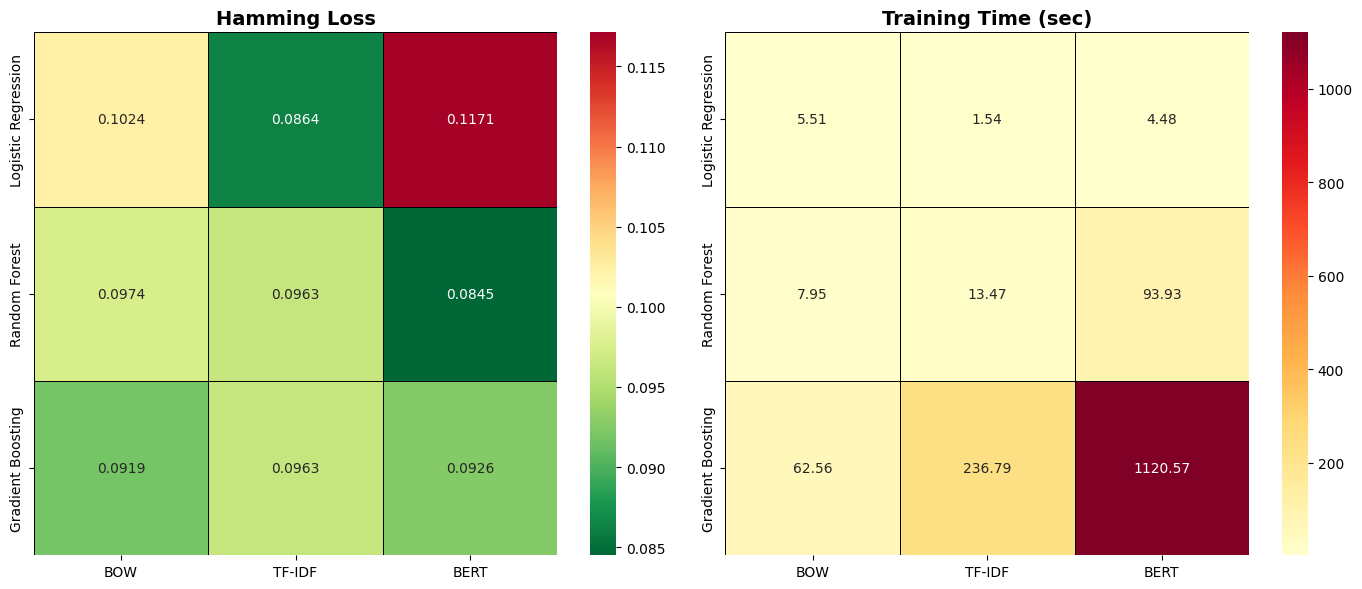

In [ ]:
results_df = pd.DataFrame(all_results)

# Create summary tables for heatmaps
hamming_loss_df = results_df.map(lambda x: x['hamming_loss'])
time_df = results_df.map(lambda x: x['train_time'])

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Hamming loss
sns.heatmap(
    hamming_loss_df,
    annot=True,
    fmt='.4f',
    cmap='RdYlGn_r',
    linewidths=0.5,
    linecolor='black',
    ax=axes[0]
)
axes[0].set_title('Hamming Loss', fontsize=14, fontweight='bold')

# Training time
sns.heatmap(
    time_df,
    annot=True,
    fmt='.2f',
    cmap='YlOrRd',
    linewidths=0.5,
    linecolor='black',
    ax=axes[1]
)
axes[1].set_title('Training Time (sec)', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig("hamming_loss_training_time.png")
plt.show()

Accuracy distribution by class:

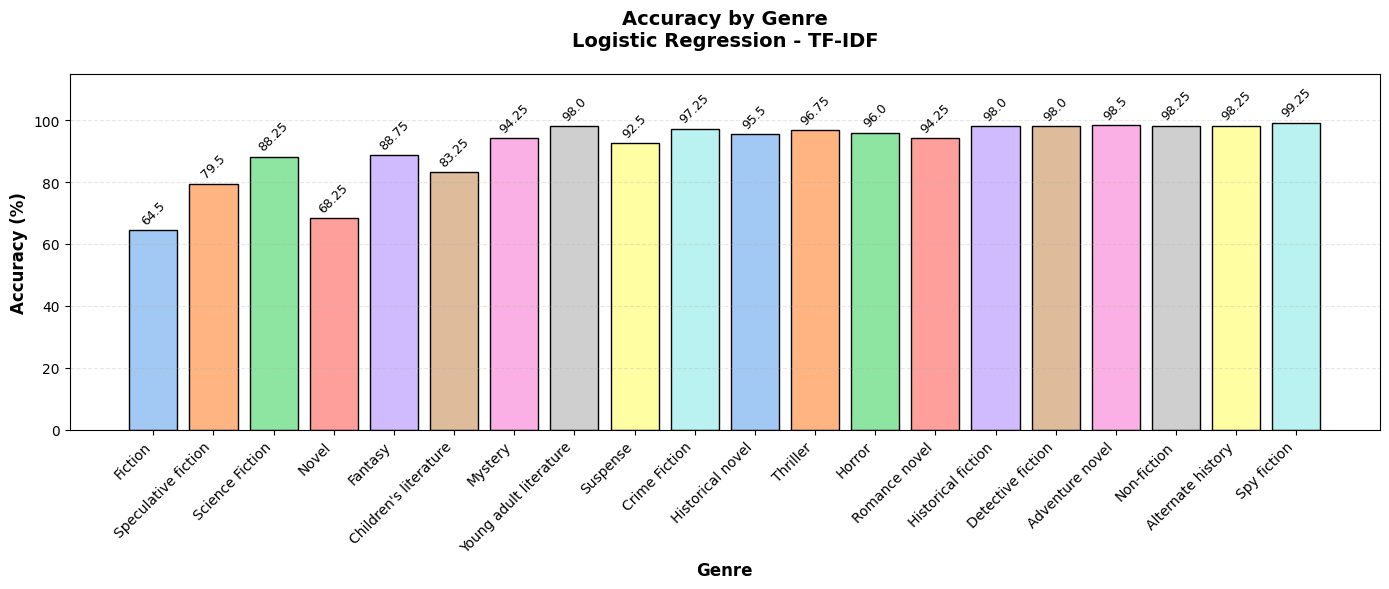

In [ ]:
### TF-IDF
### Logistic Regression

features_type = 'TF-IDF'
model_name = 'Logistic Regression'

result = all_results[features_type][model_name]
accuracy_per_class = result['accuracy_per_class']

accuracy_df = pd.DataFrame({
    'Genre': list(accuracy_per_class.keys()),
    'Accuracy': list(accuracy_per_class.values())
})

# Bar chart creation
colors = sns.color_palette("pastel", len(accuracy_df))
plt.figure(figsize=(14, 6))
bars = plt.bar(accuracy_df['Genre'], accuracy_df['Accuracy']*100,
               color=colors, edgecolor='black', linewidth=1.0)

# Sign values over columns
for bar, acc in zip(bars, accuracy_df['Accuracy']):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
             acc*100, ha='center', va='bottom', fontsize=9, rotation=45)

plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(fontsize=10)
plt.grid(axis='y', alpha=0.3, linestyle='--')
plt.ylim(0, 115)
plt.xlabel('Genre', fontsize=12, fontweight='bold')
plt.ylabel('Accuracy (%)', fontsize=12, fontweight='bold')
plt.title(f'Accuracy by Genre\n{model_name} - {features_type}', fontsize=14, fontweight='bold', pad=20)

plt.tight_layout()
plt.savefig("accuracy_logreg_tfidf.png")
plt.show()

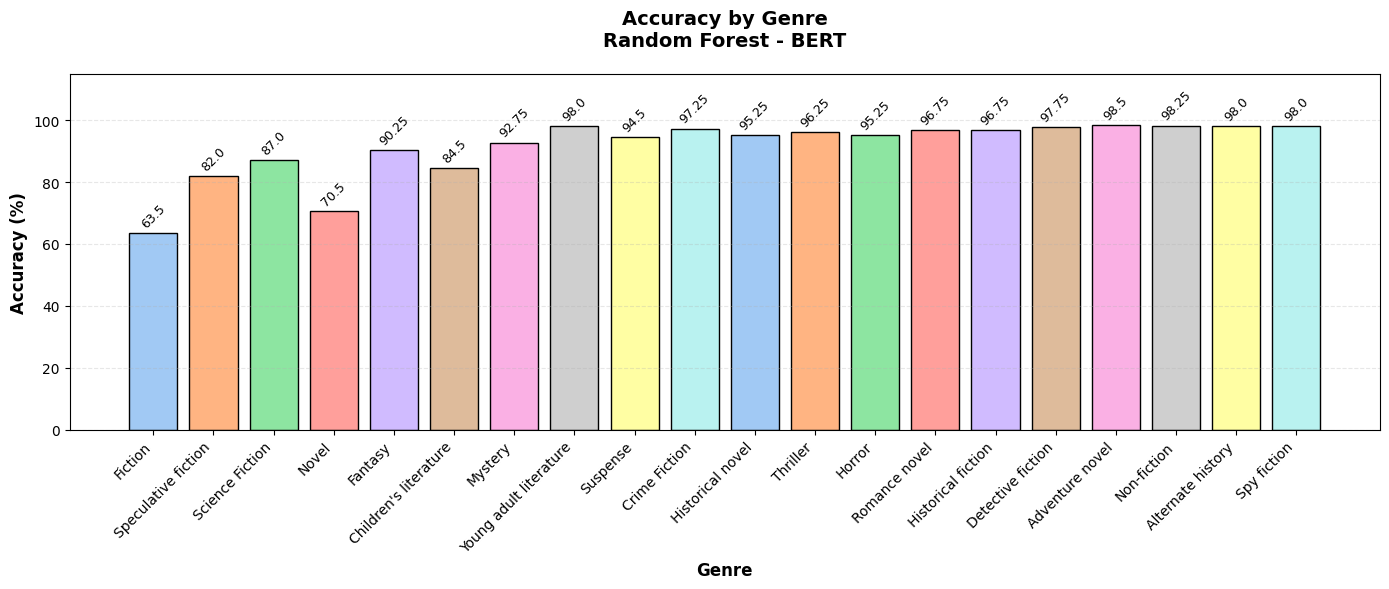

In [ ]:
### BERT
### Random Forest

features_type = 'BERT'
model_name = 'Random Forest'

result = all_results[features_type][model_name]
accuracy_per_class = result['accuracy_per_class']

accuracy_df = pd.DataFrame({
    'Genre': list(accuracy_per_class.keys()),
    'Accuracy': list(accuracy_per_class.values())
})

# Bar chart creation
colors = sns.color_palette("pastel", len(accuracy_df))
plt.figure(figsize=(14, 6))
bars = plt.bar(accuracy_df['Genre'], accuracy_df['Accuracy']*100,
               color=colors, edgecolor='black', linewidth=1.0)

# Sign values over columns
for bar, acc in zip(bars, accuracy_df['Accuracy']):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
             acc*100, ha='center', va='bottom', fontsize=9, rotation=45)

plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(fontsize=10)
plt.grid(axis='y', alpha=0.3, linestyle='--')
plt.ylim(0, 115)
plt.xlabel('Genre', fontsize=12, fontweight='bold')
plt.ylabel('Accuracy (%)', fontsize=12, fontweight='bold')
plt.title(f'Accuracy by Genre\n{model_name} - {features_type}', fontsize=14, fontweight='bold', pad=20)

plt.tight_layout()
plt.savefig("accuracy_randforest_bert.png")
plt.show()

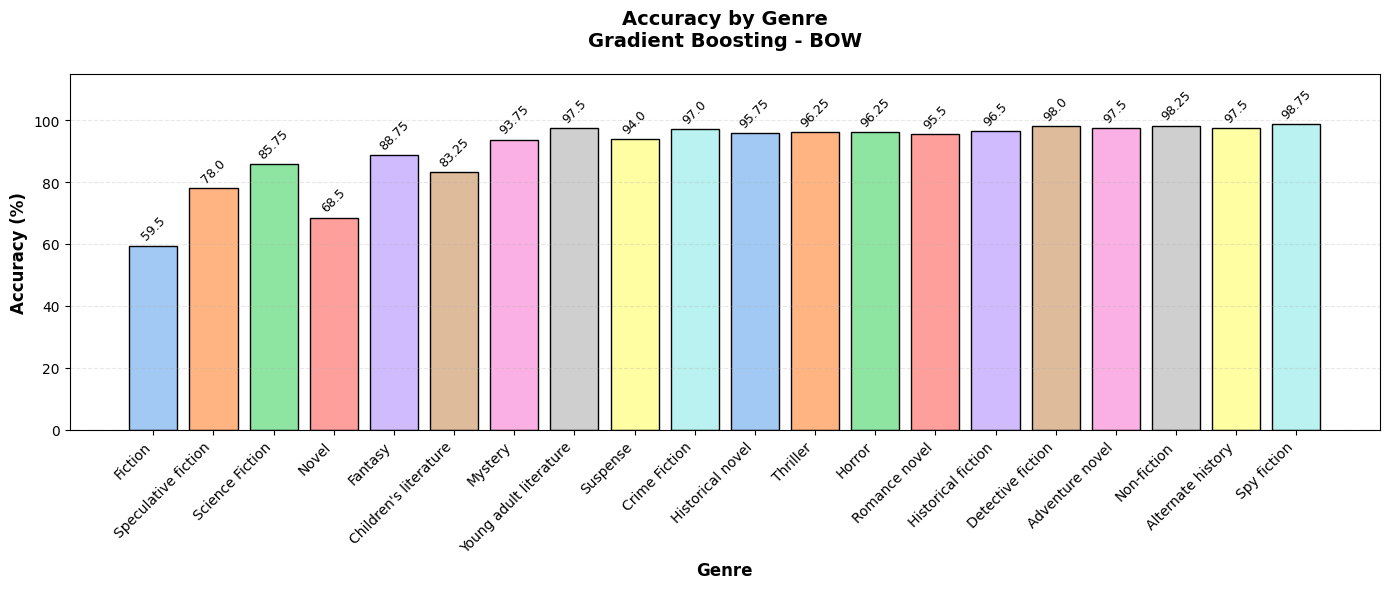

In [ ]:
# BOW
# Gradient Boosting

features_type = 'BOW'
model_name = 'Gradient Boosting'

result = all_results[features_type][model_name]
accuracy_per_class = result['accuracy_per_class']

accuracy_df = pd.DataFrame({
    'Genre': list(accuracy_per_class.keys()),
    'Accuracy': list(accuracy_per_class.values())
})

# Bar chart creation
colors = sns.color_palette("pastel", len(accuracy_df))
plt.figure(figsize=(14, 6))
bars = plt.bar(accuracy_df['Genre'], accuracy_df['Accuracy']*100,
               color=colors, edgecolor='black', linewidth=1.0)

# Sign values over columns
for bar, acc in zip(bars, accuracy_df['Accuracy']):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
             acc*100, ha='center', va='bottom', fontsize=9, rotation=45)

plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(fontsize=10)
plt.grid(axis='y', alpha=0.3, linestyle='--')
plt.ylim(0, 115)
plt.xlabel('Genre', fontsize=12, fontweight='bold')
plt.ylabel('Accuracy (%)', fontsize=12, fontweight='bold')
plt.title(f'Accuracy by Genre\n{model_name} - {features_type}', fontsize=14, fontweight='bold', pad=20)

plt.tight_layout()
plt.savefig("accuracy_gradboost_bow.png")
plt.show()

True and predicted genres for some examples (BERT, Random Forest):

In [ ]:
def get_genres(arr):
    """Transform label matrix to list of genres"""

    return [[target_genres[i] for i, val in enumerate(row) if val == 1] for row in arr]

features_type = 'BERT'
model_name = 'Random Forest'

result = all_results[features_type][model_name]
y_pred = result['y_pred']

# Get indices of X_test
if hasattr(X_test, 'index'):
    test_indices = X_test.index
else:
    test_indices = range(len(X_test))

# DataFrame with results
results_df = pd.DataFrame()
results_df['Book Title'] = data.loc[test_indices, 'title'].values
results_df['Summary'] = X_test.values if hasattr(X_test, 'values') else X_test

# Append true and predicted values
results_df['True Genres'] = (get_genres(list(y_test)))
results_df['Predicted Genres'] = get_genres(list(y_pred))

results_df[['Book Title', 'True Genres', 'Predicted Genres']].head(20)

,Book Title,True Genres,Predicted Genres
0,Endymion,[Novel],[Fiction]
1,Foucault's Pendulum,[Speculative fiction],"[Fiction, Speculative fiction]"
2,The Leopard,"[Fiction, Novel]",[Fiction]
3,K-PAX,"[Fiction, Speculative fiction, Science Fiction...","[Fiction, Speculative fiction]"
4,Summer of Night,"[Speculative fiction, Horror]","[Fiction, Speculative fiction]"
5,And the Ass Saw the Angel,"[Fiction, Novel]",[Speculative fiction]
6,Sabriel,"[Fiction, Speculative fiction, Science Fiction...","[Fiction, Speculative fiction, Fantasy]"
7,Hatshepsut: Daughter of Amun,[Historical novel],[Speculative fiction]
8,Lord of the Flies,"[Fiction, Speculative fiction, Novel, Young ad...","[Fiction, Speculative fiction]"
9,Royal Assassin,"[Fiction, Speculative fiction, Science Fiction...","[Fiction, Speculative fiction, Fantasy]"


### Conclusion

Optimal strategies:
1) For `Logistic Regression` - `TF-IDF`;
2) For `Random Forest` - `BERT`;
3) For `Gradient Boosting` - `BOW`.

Best combination: `Random Forest`, `BERT` (hamming loss = $0.0845$).

According to accuracy distribution:
1) Classification is less precise for common genres than for rare ones.
2) Specialized genres demonstrate noticeably higher classification performance compared to comprehensive categories like Fiction and Novel.